In [3]:
%pycat ce_amp_1_orig.cir

Common Emitter Amplifier
* Supply and bias
Vcc vcc 0 DC $VCC
Rb1 vcc base $RB1
Rb2 base 0 $RB2
Rc  vcc col $RC
Re  emit 0 $RE

* BJT
Q1 col base emit BC547

* Input signal (AC coupled)
Vin sig 0 SIN(0 $VAMP $FREQ)
Cin sig base $CIN
Cout col out $COUT
RL  out 0 $RL

.MODEL BC547 NPN(Is=1e-14 Bf=200 Vaf=100)

.OP
.TRAN $TSTEP $TEND

.SAVE v(base) v(col) v(emit) v(out)
.END


In [4]:
import ngspice_calc as calc
import numpy as np

In [19]:

s_VCC = '12'

s_RB1 = '100k'
s_RB2 = '22k'
s_RC = '3.3k'
s_RE = '1k'

s_VAMP = '0.01'
s_FREQ = '10k'
s_CIN = '10u'
s_COUT = '10u'
s_RL = '10k'

vcc=12.0
rc=3300.0
freq = 10e3
T = 1.0/freq
Tstep = T/200
Tend = 10*T

l = [
    ('$VCC',  s_VCC),
    ('$RB1',  s_RB1),
    ('$RB2',  s_RB2),
    ('$RC',   s_RC),
    ('$RE',   s_RE),
    ('$VAMP', s_VAMP),
    ('$FREQ', s_FREQ),
    ('$CIN',  s_CIN),
    ('$COUT', s_COUT),
    ('$RL',   s_RL),
    ('$TSTEP', f'{Tstep:.8f}'),
    ('$TEND',  f'{Tend:.6f}'),
    ('$SAVE_VARS', f'v(base) v(col) v(emit) v(out)')
]

calc.replace_strings_1('ce_amp_1_orig.cir', 'ce_amp_1.cir', l)
print("ce_amp_1.cir ready for execution")

ce_amp_1.cir ready for execution


In [20]:
calc.run_ngspice('ce_amp_1.cir')


Note: No compatibility mode selected!


Circuit: common emitter amplifier

binary raw file "ce_amp_1.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver
No. of Data Columns : 4  

No. of Data Rows : 1
No. of Data Columns : 5  

Initial Transient Solution
--------------------------

Node                                   Voltage
----                                   -------
vcc                                         12
base                                    2.0461
col                                    7.45418
emit                                   1.38405
sig                                          0
out                                          0
vin#branch                                   0
vcc#branch                         -0.00147706


No. of Data Rows : 2008

Total analysis time (seconds) = 0.00990786

Total elapsed time (seconds) = 0.013 

Total DRAM available = 15614.746 MB.
DRAM currently available = 2436.680 MB.
Maximum 

'ce_amp_1.raw'

In [21]:
s = calc.slv('ce_amp_1.cir')

print("Number of plots: ", s.num_plots())
for i in range(s.num_plots()):
    print(f'plot {i}: {s.plotname(i)} | type: {s.analysis_type(i)} | variables: {s.variables(i)}')

Number of plots:  2
plot 0: Operating Point | type: op | variables: ['v(base)', 'v(col)', 'v(emit)', 'v(out)']
plot 1: Transient Analysis | type: tran | variables: ['time', 'v(base)', 'v(col)', 'v(emit)', 'v(out)']


In [22]:
v_base = s.get_array('v(base)', plot=0)[0]
v_col = s.get_array('v(col)', plot=0)[0]
v_emit = s.get_array('v(emit)', plot=0)[0]

vce = v_col - v_emit
vbe = v_base - v_emit
ic = (vcc - v_col) / rc

print('DC Operating Point')
print(f'V(base) = {v_base:.4f} V')
print(f'V(col) = {v_col:.4f} V')
print(f'V(emit) = {v_emit:.4f} V')
print(f'VBE = {vbe:.4f} V')
print(f'VCE = {vce:.4f} V')
print(f'IC = {ic*1e3:.4f} mA')

DC Operating Point
V(base) = 2.0461 V
V(col) = 7.4542 V
V(emit) = 1.3841 V
VBE = 0.6620 V
VCE = 6.0701 V
IC = 1.3775 mA


In [24]:
t = s.get_array('time', plot=1)
vin = s.get_array('v(base)', plot=1)
vout = s.get_array('v(out)', plot=1)

vin_amp = (vin.max() - vin.min())/2
vout_amp = (vout.max() - vout.min())/2
gain = vout_amp/vin_amp if vin_amp>0 else 0

print(f'Input amplitude: {vin_amp*1e3:.3f} mV')
print(f'Output amplitude: {vout_amp*1e3:.3f} mV')
print(f'Voltage gain: {gain:.2f}')

Input amplitude: 10.000 mV
Output amplitude: 24.215 mV
Voltage gain: 2.42


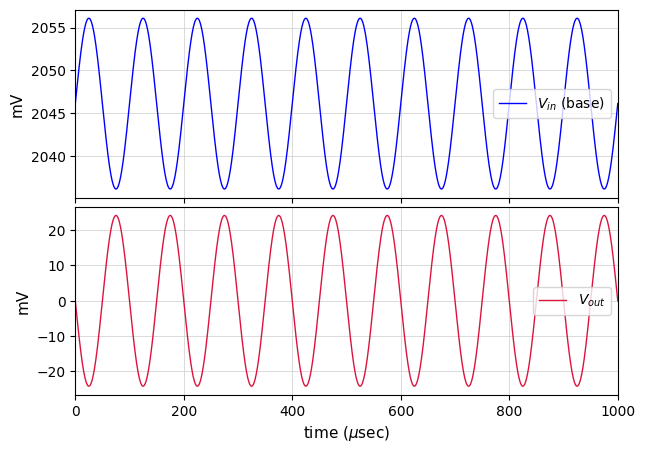

In [25]:
color1 = 'blue'
color2 = 'crimson'

fig, ax = plt.subplots(2, sharex=True, figsize=(7, 5))
plt.subplots_adjust(hspace=0.05)

for a in ax:
    a.grid(color='#CCCCCC', linestyle='solid', linewidth=0.5)
    a.set_xlim(left=0.0, right=t[-1]*1e6)

ax[0].plot(t*1e6, vin*1e3,  color=color1, linewidth=1.0, label=r'$V_{in}$ (base)')
ax[0].set_ylabel('mV', fontsize=11)
ax[0].legend(fontsize=10)
ax[0].tick_params(labelbottom=False)

ax[1].plot(t*1e6, vout*1e3, color=color2, linewidth=1.0, label=r'$V_{out}$')
ax[1].set_ylabel('mV', fontsize=11)
ax[1].set_xlabel(r'time ($\mu$sec)', fontsize=11)
ax[1].legend(fontsize=10)

plt.show()